# Formation Parameter Search — Results Analysis

Analyzes output from `scripts/formation_search.py`.

**Workflow:**
1. Run this notebook to identify formation combos that pass quality thresholds
2. Copy surviving combos into `FORMATION_GRID` in `scripts/grid_search_v2.py`
3. Run `grid_search_v2.py --phase 2` to sweep signal params on the shortlisted combos

**Selection criteria (Stage A → B gate):**
- `mean_n_pairs ≥ 5` — minimum diversification
- `pct_days_with_pairs ≥ 50%` — pairs available on most trading days
- `split_consistency_rate ≥ 40%` — at least 40% of pairs pass both half-window ADF tests

**Final combo selection (after Stage B signal sweep):**
- `ic_t_stat > 1.96` AND `mean_ic_gross > 0` AND `breakeven_bps > cost_bps`
- Rank survivors by `mean_net_return` at the 4-bar (1hr) horizon

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_PATH = Path('../results/formation_search.parquet')

# Minimum quality thresholds (must match formation_search.py)
THRESHOLDS = {
    'mean_n_pairs': 5.0,
    'pct_days_with_pairs': 0.50,
    'split_consistency_rate': 0.40,
}

In [2]:
df = pl.read_parquet(RESULTS_PATH).sort('composite_score', descending=True)
print(f'Loaded {len(df)} formation combos')
print(f'Columns: {df.columns}')
df.head(10)

Loaded 81 formation combos
Columns: ['rolling_window_days', 'min_half_life', 'max_half_life', 'p_value_threshold', 'n_days_evaluated', 'mean_n_pairs', 'pct_days_with_pairs', 'split_consistency_rate', 'mean_n_sectors', 'mean_hedge_ratio_cv', 'mean_half_life', 'composite_score']


rolling_window_days,min_half_life,max_half_life,p_value_threshold,n_days_evaluated,mean_n_pairs,pct_days_with_pairs,split_consistency_rate,mean_n_sectors,mean_hedge_ratio_cv,mean_half_life,composite_score
i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64
84,2,48,0.05,92,123.83,1.0,0.086,8.0,0.4515,39.04,3.3122
84,4,48,0.05,92,123.83,1.0,0.086,8.0,0.4515,39.04,3.3122
84,8,48,0.05,92,123.83,1.0,0.086,8.0,0.4515,39.04,3.3122
21,2,12,0.05,92,152.34,1.0,0.079,7.95,1.0277,9.56,3.1635
42,2,24,0.05,92,151.92,1.0,0.077,7.98,0.9105,19.31,3.0987
42,4,24,0.05,92,151.92,1.0,0.077,7.98,0.9105,19.31,3.0987
21,4,12,0.05,92,151.53,1.0,0.078,7.95,1.0338,9.59,3.0949
42,8,24,0.05,92,151.51,1.0,0.076,7.98,0.9112,19.34,3.0541
42,2,12,0.05,92,5.03,1.0,0.495,2.66,0.2,10.39,2.1306


## 1. Full Ranked Table

In [3]:
display_cols = [
    'rolling_window_days', 'min_half_life', 'max_half_life', 'p_value_threshold',
    'mean_n_pairs', 'pct_days_with_pairs', 'split_consistency_rate',
    'mean_n_sectors', 'mean_hedge_ratio_cv', 'mean_half_life', 'composite_score'
]
display_cols = [c for c in display_cols if c in df.columns]
print('All combos ranked by composite_score:')
print(df.select(display_cols).to_pandas().to_string(index=False))

All combos ranked by composite_score:
 rolling_window_days  min_half_life  max_half_life  p_value_threshold  mean_n_pairs  pct_days_with_pairs  split_consistency_rate  mean_n_sectors  mean_hedge_ratio_cv  mean_half_life  composite_score
                  84              2             48              0.050        123.83                1.000                   0.086            8.00               0.4515           39.04           3.3122
                  84              4             48              0.050        123.83                1.000                   0.086            8.00               0.4515           39.04           3.3122
                  84              8             48              0.050        123.83                1.000                   0.086            8.00               0.4515           39.04           3.3122
                  21              2             12              0.050        152.34                1.000                   0.079            7.95               1.0277 

## 2. Quality Threshold Filter — Survivors

In [4]:
survivors = df
for col, thresh in THRESHOLDS.items():
    survivors = survivors.filter(pl.col(col) >= thresh)

print(f'Survivors: {len(survivors)} / {len(df)} combos pass all thresholds')
print(f'  mean_n_pairs          ≥ {THRESHOLDS["mean_n_pairs"]}')
print(f'  pct_days_with_pairs   ≥ {THRESHOLDS["pct_days_with_pairs"]:.0%}')
print(f'  split_consistency_rate ≥ {THRESHOLDS["split_consistency_rate"]:.0%}')
print()
if len(survivors) > 0:
    print(survivors.select(display_cols).to_pandas().to_string(index=False))
else:
    print('No survivors — consider relaxing thresholds.')

Survivors: 2 / 81 combos pass all thresholds
  mean_n_pairs          ≥ 5.0
  pct_days_with_pairs   ≥ 50%
  split_consistency_rate ≥ 40%

 rolling_window_days  min_half_life  max_half_life  p_value_threshold  mean_n_pairs  pct_days_with_pairs  split_consistency_rate  mean_n_sectors  mean_hedge_ratio_cv  mean_half_life  composite_score
                  42              2             12               0.05          5.03                  1.0                   0.495            2.66                  0.2           10.39           2.1306
                  42              4             12               0.05          5.03                  1.0                   0.495            2.66                  0.2           10.39           2.1306


## 3. Parameter Sensitivity — Split Consistency Rate

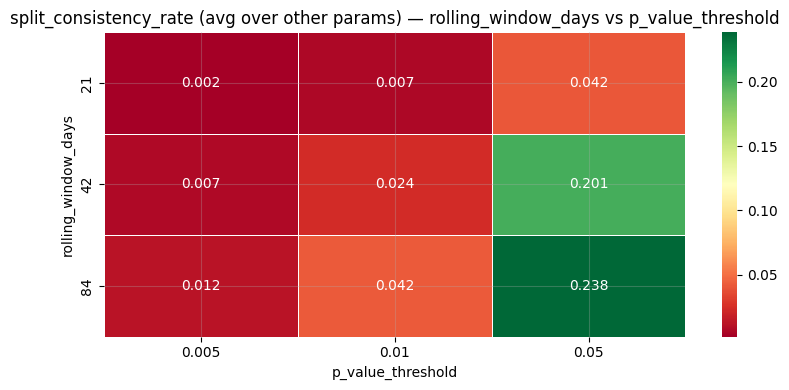

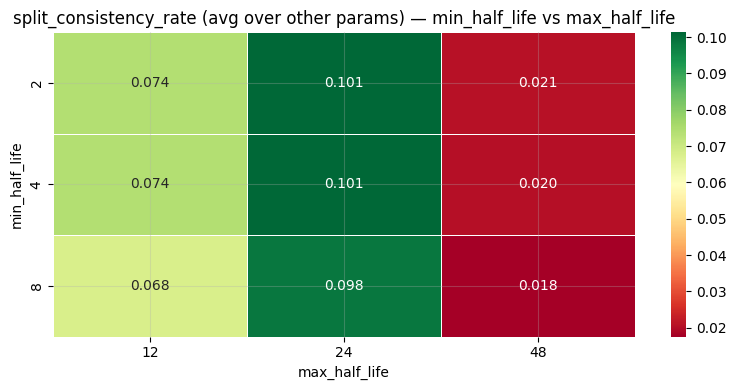

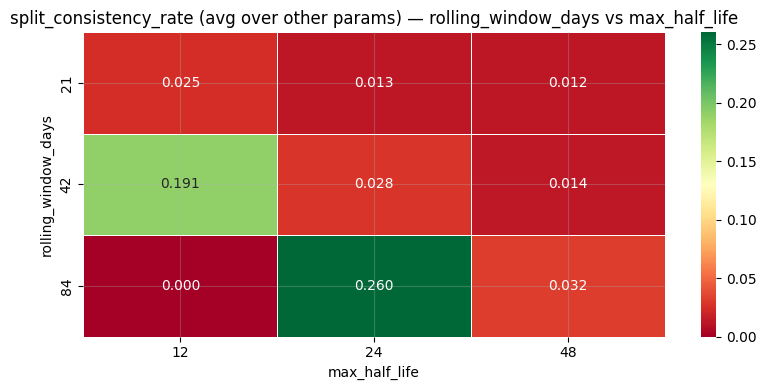

In [5]:
def param_heatmap(df_pd, row_param, col_param, metric, title_suffix='', vmin=None, vmax=None, center=None):
    pivot = (
        df_pd.groupby([row_param, col_param])[metric].mean().reset_index()
        .pivot(index=row_param, columns=col_param, values=metric)
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    cmap = 'RdYlGn'
    _vmax = vmax or abs(pivot.values[np.isfinite(pivot.values)]).max()
    _vmin = vmin or (-_vmax if center == 0 else None)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                vmin=_vmin, vmax=_vmax, center=center,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{metric} (avg over other params) — {row_param} vs {col_param}{title_suffix}')
    plt.tight_layout()
    plt.show()

df_pd = df.to_pandas()

param_heatmap(df_pd, 'rolling_window_days', 'p_value_threshold', 'split_consistency_rate')
param_heatmap(df_pd, 'min_half_life', 'max_half_life', 'split_consistency_rate')
param_heatmap(df_pd, 'rolling_window_days', 'max_half_life', 'split_consistency_rate')

## 4. Parameter Sensitivity — Pair Count

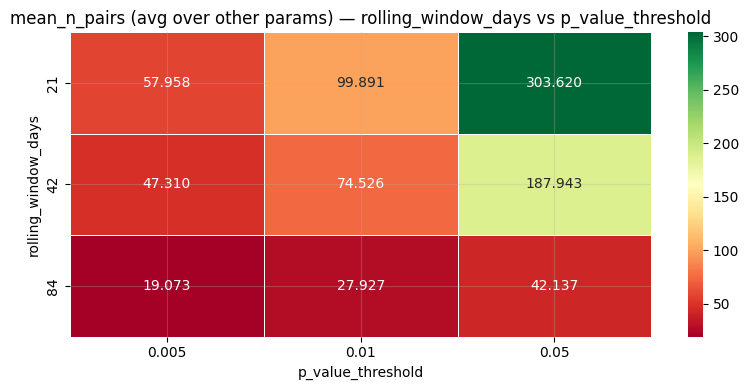

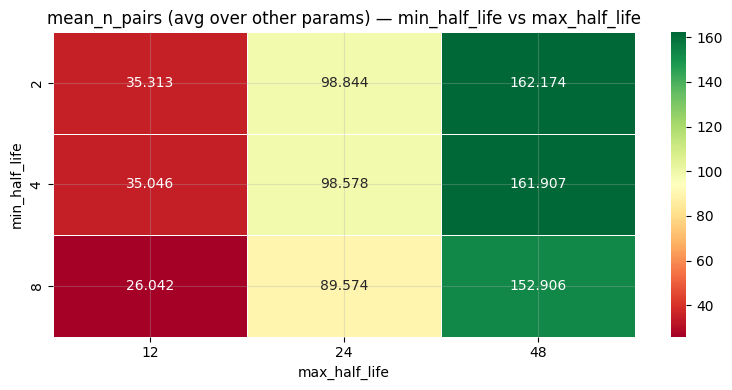

In [6]:
param_heatmap(df_pd, 'rolling_window_days', 'p_value_threshold', 'mean_n_pairs', vmin=0)
param_heatmap(df_pd, 'min_half_life', 'max_half_life', 'mean_n_pairs', vmin=0)

## 5. Stability vs. Capacity Trade-off

Ideal combos: high split_consistency_rate AND many pairs. This scatter shows the trade-off.

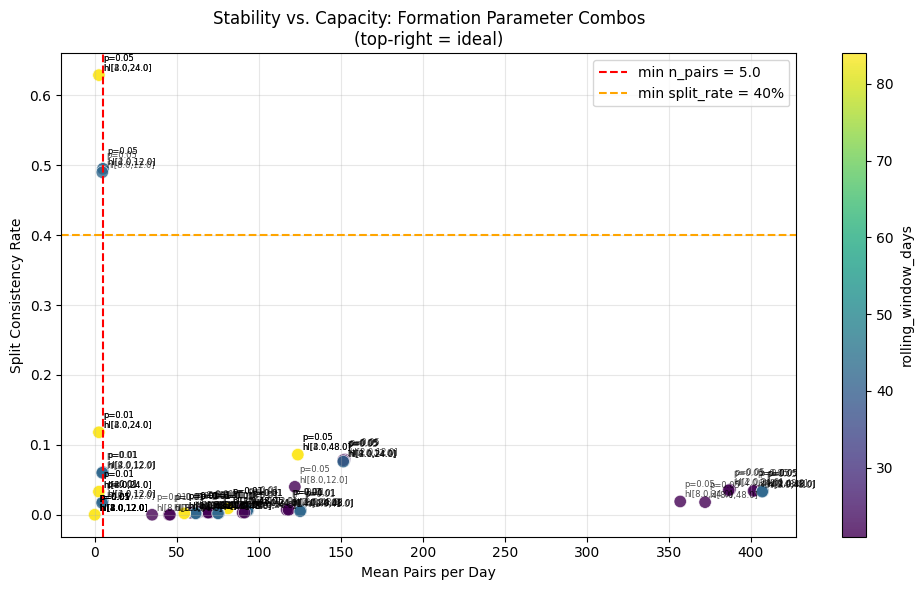

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df_pd['mean_n_pairs'],
    df_pd['split_consistency_rate'],
    c=df_pd['rolling_window_days'],
    cmap='viridis', s=80, alpha=0.8, edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='rolling_window_days')

# Mark threshold box
ax.axvline(THRESHOLDS['mean_n_pairs'], color='red', linewidth=1.5, linestyle='--',
           label=f'min n_pairs = {THRESHOLDS["mean_n_pairs"]}')
ax.axhline(THRESHOLDS['split_consistency_rate'], color='orange', linewidth=1.5, linestyle='--',
           label=f'min split_rate = {THRESHOLDS["split_consistency_rate"]:.0%}')

# Annotate p_value_threshold
for _, row in df_pd.iterrows():
    ax.annotate(
        f"p={row['p_value_threshold']:.2f}\nhl[{row['min_half_life']},{row['max_half_life']}]",
        xy=(row['mean_n_pairs'], row['split_consistency_rate']),
        xytext=(3, 3), textcoords='offset points', fontsize=6, alpha=0.7
    )

ax.set_xlabel('Mean Pairs per Day')
ax.set_ylabel('Split Consistency Rate')
ax.set_title('Stability vs. Capacity: Formation Parameter Combos\n(top-right = ideal)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Hedge Ratio CV Distribution

Lower hedge ratio CV = more stable cointegrating relationship = safer to trade with fixed β.

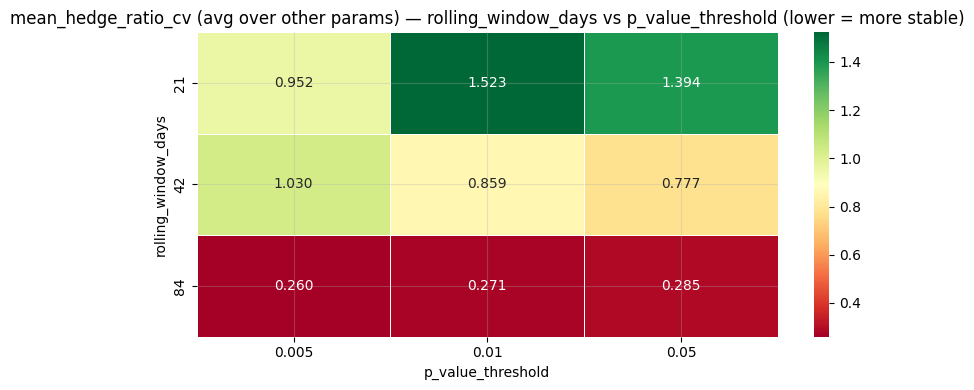

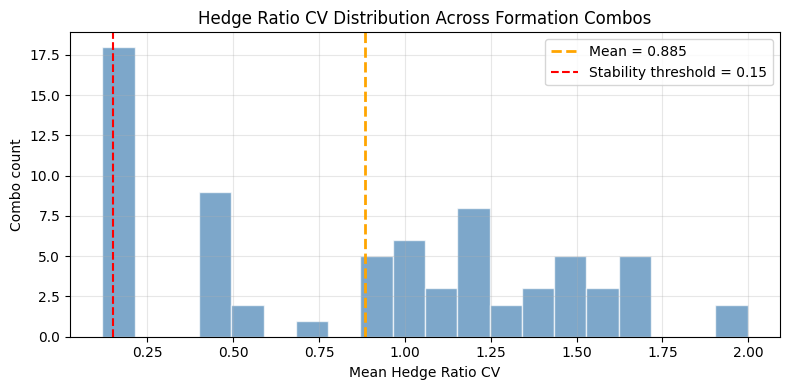

In [8]:
if 'mean_hedge_ratio_cv' in df_pd.columns:
    param_heatmap(df_pd, 'rolling_window_days', 'p_value_threshold', 'mean_hedge_ratio_cv',
                  vmin=0, title_suffix=' (lower = more stable)')

    fig, ax = plt.subplots(figsize=(8, 4))
    vals = df_pd['mean_hedge_ratio_cv'].dropna()
    ax.hist(vals, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(vals.mean(), color='orange', linewidth=2, linestyle='--',
               label=f'Mean = {vals.mean():.3f}')
    ax.axvline(0.15, color='red', linewidth=1.5, linestyle='--',
               label='Stability threshold = 0.15')
    ax.set_xlabel('Mean Hedge Ratio CV')
    ax.set_ylabel('Combo count')
    ax.set_title('Hedge Ratio CV Distribution Across Formation Combos')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Recommended Formation Combos

Copy the output below into `FORMATION_GRID` in `scripts/grid_search_v2.py` and run Phase 2.

In [9]:
if len(survivors) == 0:
    print('No survivors. Relax thresholds or broaden parameter ranges.')
else:
    print(f'Recommended formation combos ({len(survivors)} total):')
    print()

    # Print as Python dict for easy copy-paste into grid_search_v2.py
    grid = {
        'rolling_window_days': sorted(survivors['rolling_window_days'].unique().to_list()),
        'min_half_life': sorted(survivors['min_half_life'].unique().to_list()),
        'max_half_life': sorted(survivors['max_half_life'].unique().to_list()),
        'p_value_threshold': sorted(survivors['p_value_threshold'].unique().to_list()),
    }
    print('FORMATION_GRID = {')
    for k, v in grid.items():
        print(f'    "{k}": {v},')
    print('}')
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f'# {n_combos} formation combos for Stage B')

    print()
    print('Top 5 by composite_score:')
    print(survivors.head(5).select(display_cols).to_pandas().to_string(index=False))

Recommended formation combos (2 total):

FORMATION_GRID = {
    "rolling_window_days": [42],
    "min_half_life": [2, 4],
    "max_half_life": [12],
    "p_value_threshold": [0.05],
}
# 2 formation combos for Stage B

Top 5 by composite_score:
 rolling_window_days  min_half_life  max_half_life  p_value_threshold  mean_n_pairs  pct_days_with_pairs  split_consistency_rate  mean_n_sectors  mean_hedge_ratio_cv  mean_half_life  composite_score
                  42              2             12               0.05          5.03                  1.0                   0.495            2.66                  0.2           10.39           2.1306
                  42              4             12               0.05          5.03                  1.0                   0.495            2.66                  0.2           10.39           2.1306
